In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def read(path):
    df=pd.read_csv(path,sep=';',skiprows=2)
    df=df.iloc[:,:3]
    df.columns=["freq_Hz","re_S21","im_S21"]
    for col in ["freq_Hz","re_S21","im_S21"]:
        df[col]=pd.to_numeric(df[col],errors='coerce')
    df["mag"]=np.sqrt(df["re_S21"]**2+df["im_S21"]**2)
    df["mag_dB"]=20*np.log10(df["mag"])
    df["freq_GHz"]=df["freq_Hz"]/1e9
    return df

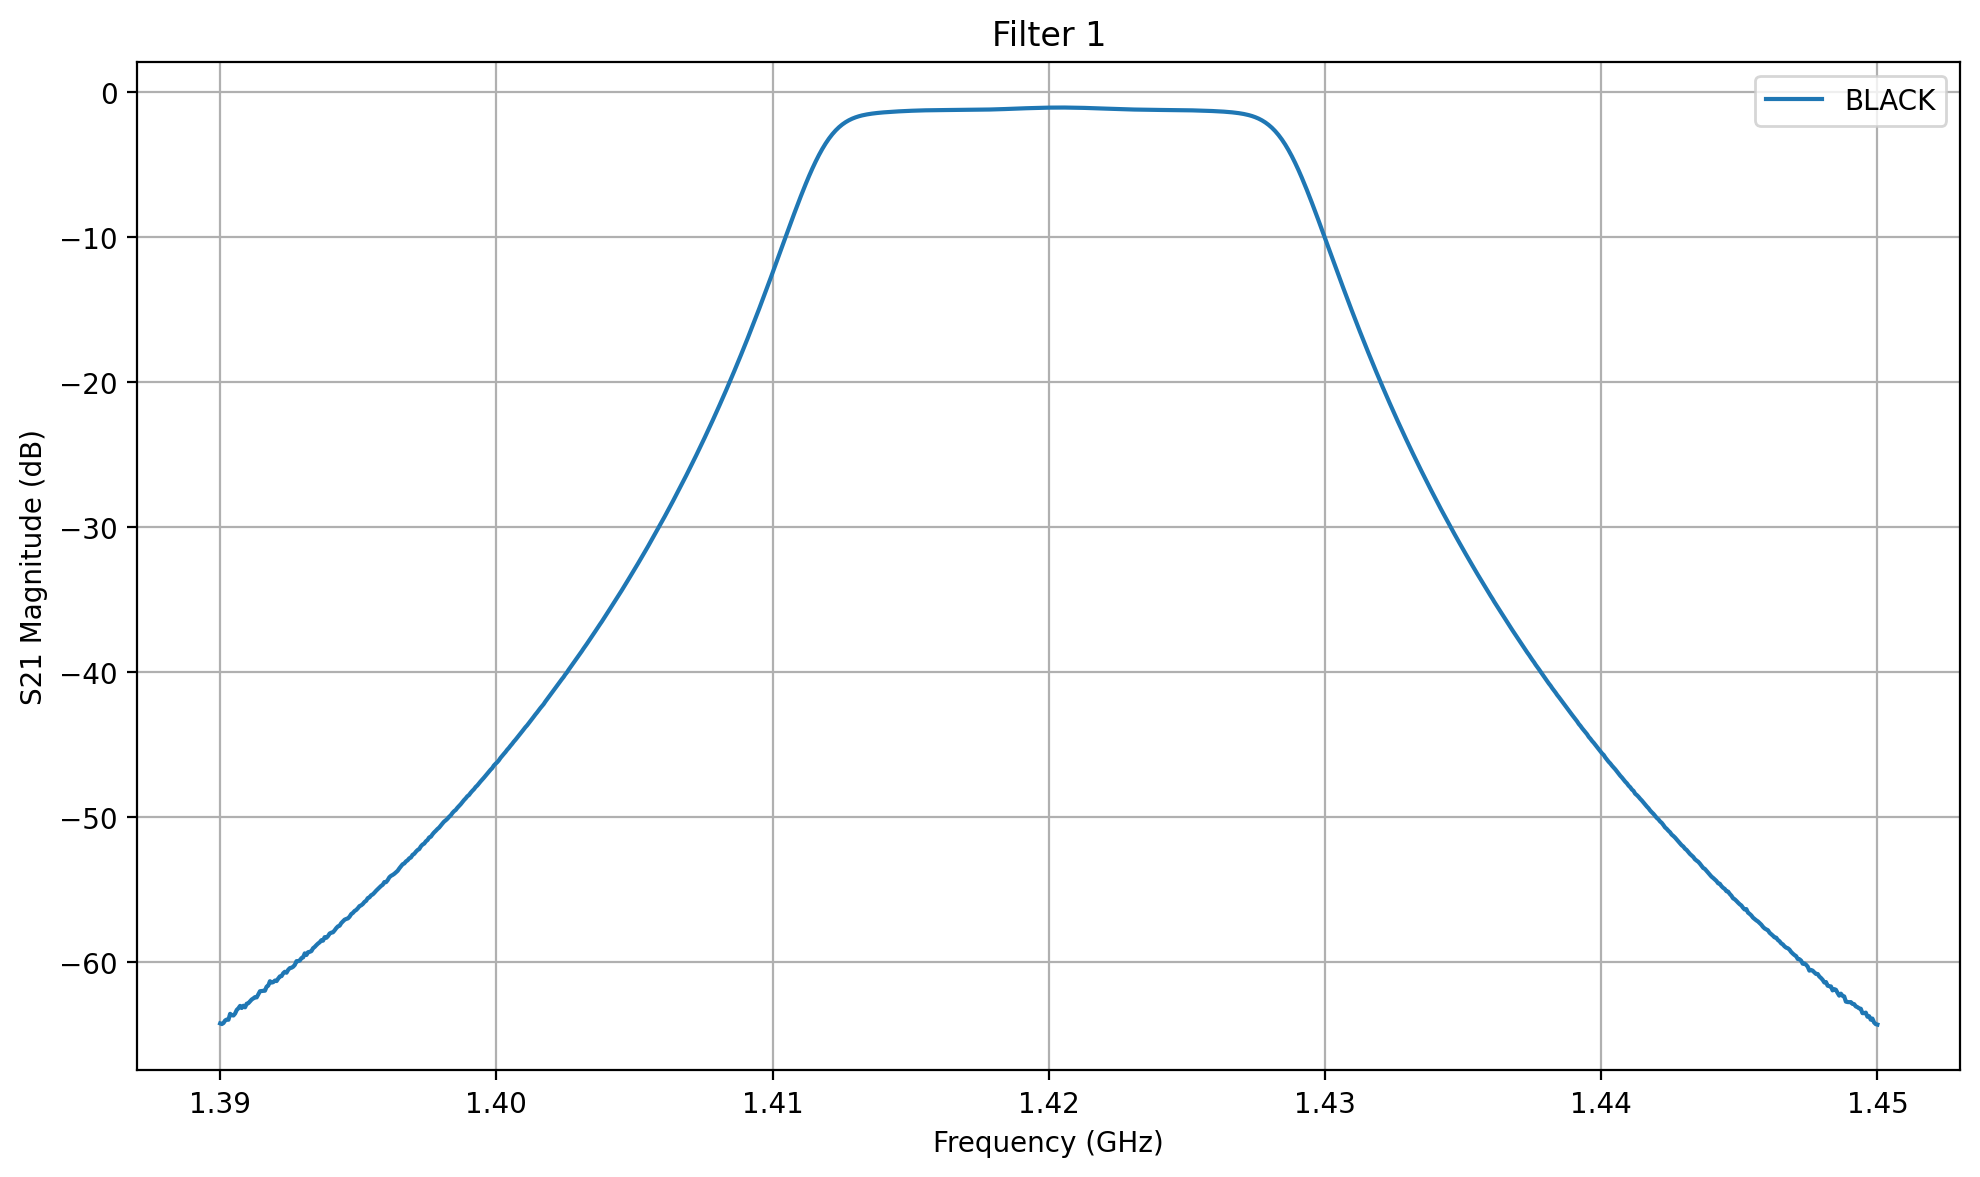

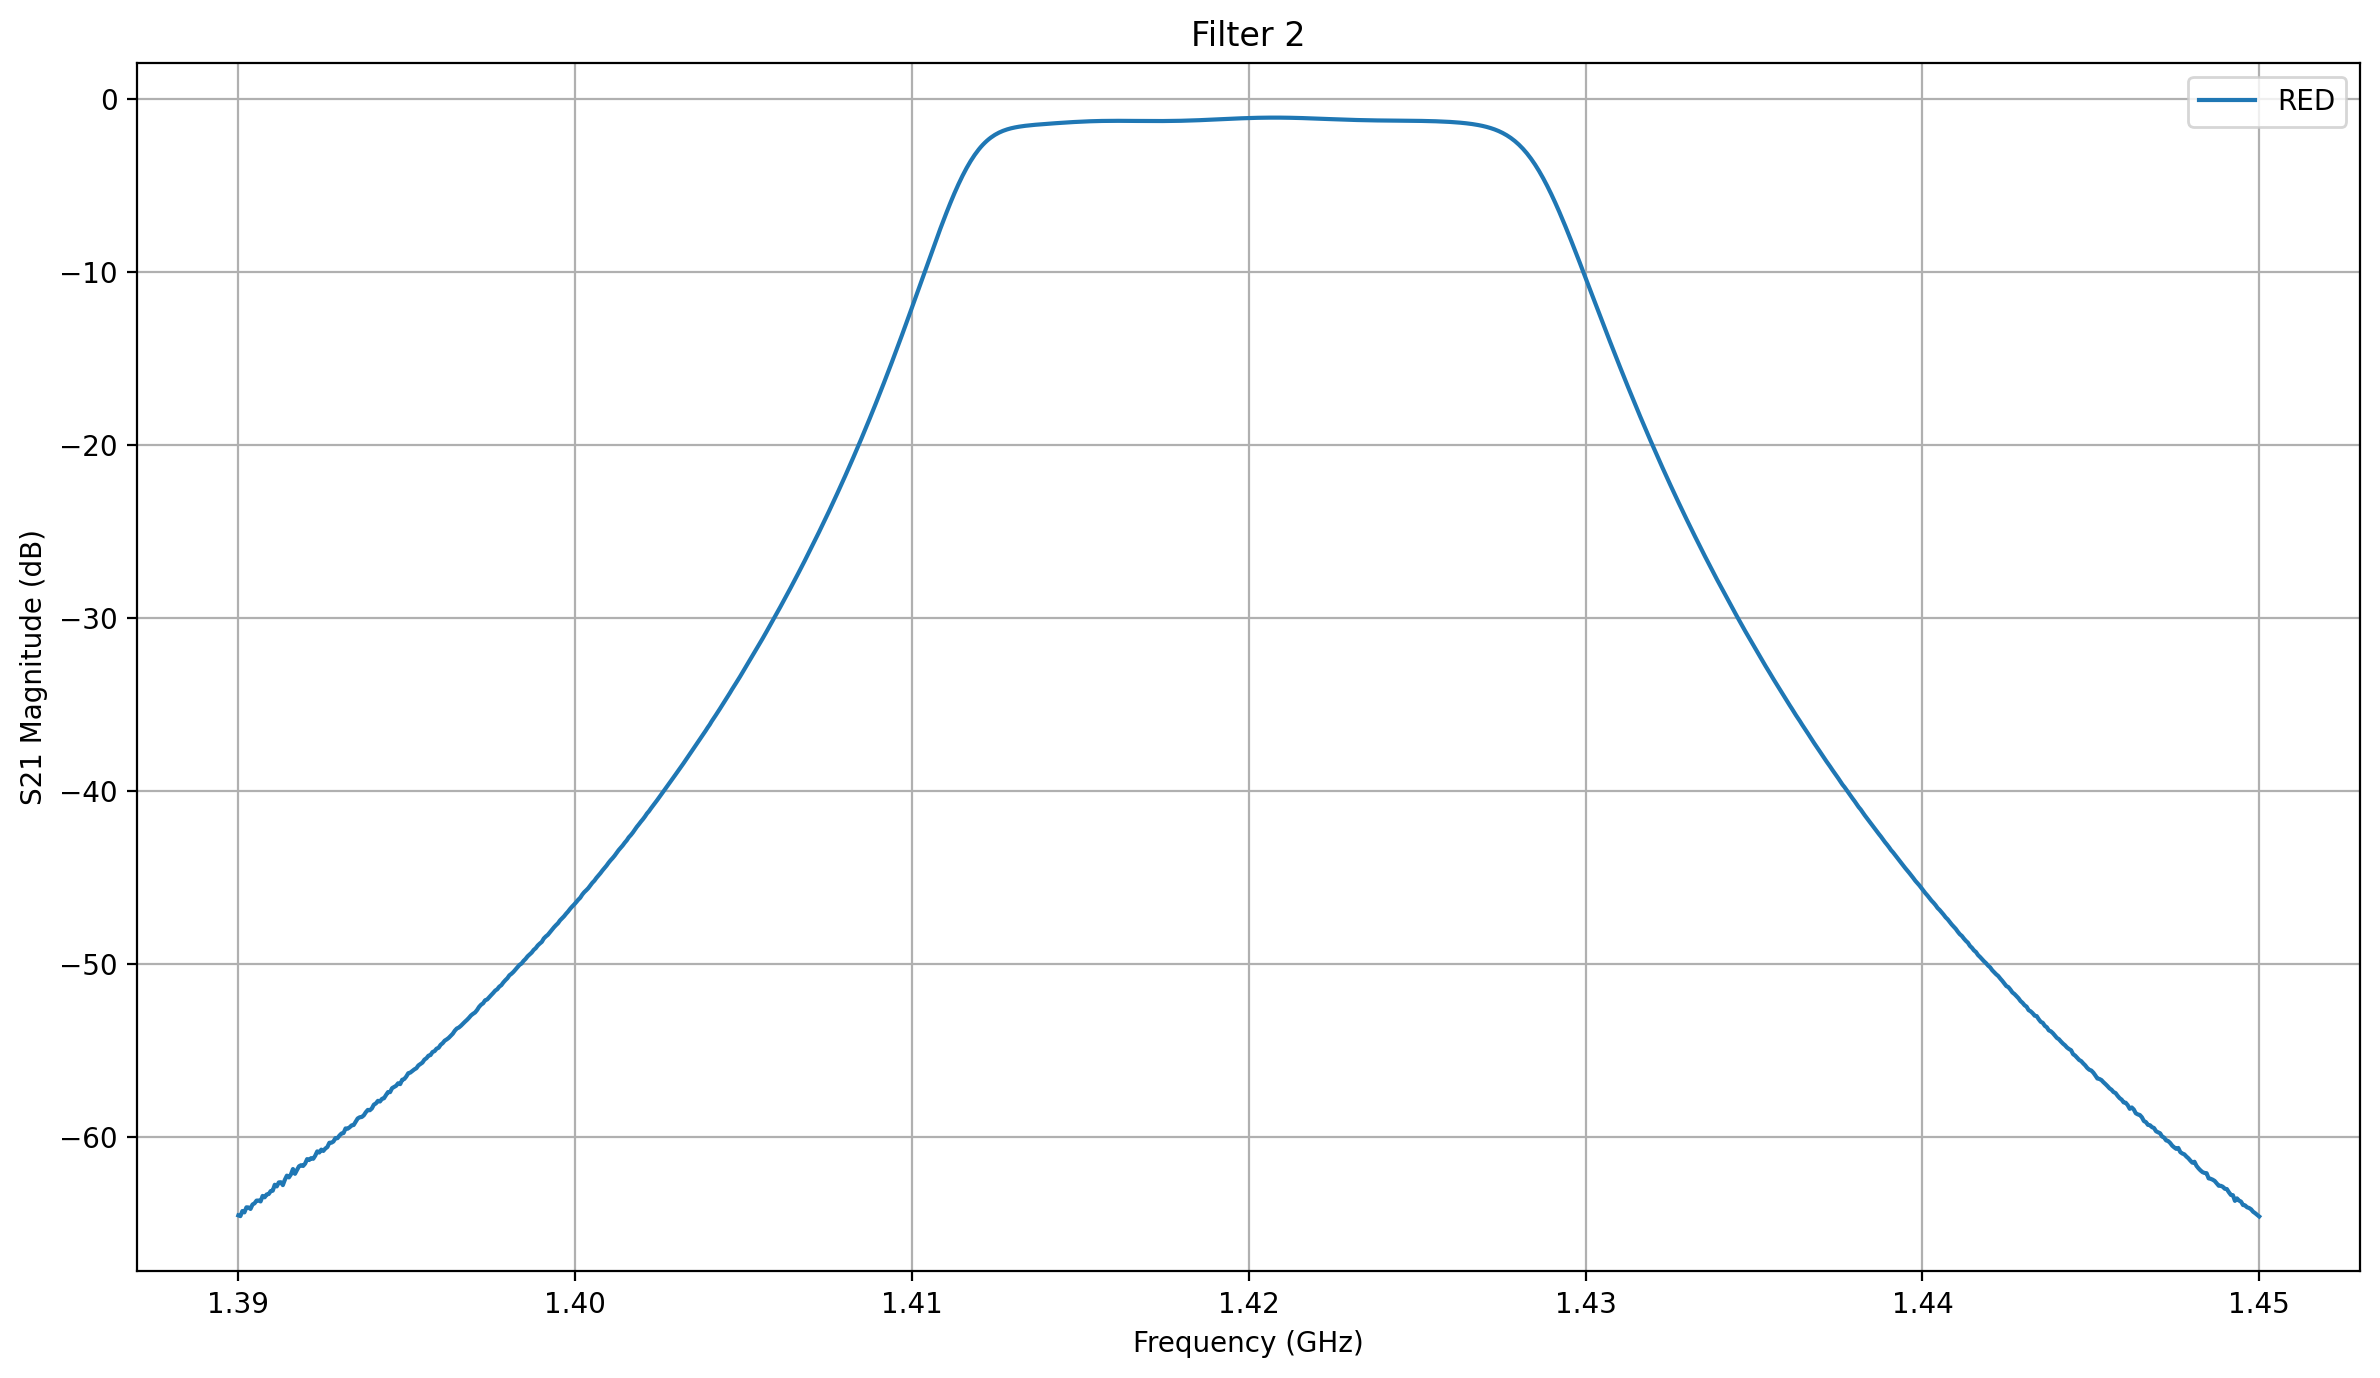

In [4]:
amp1=read("2025.11.20(1604)RED.csv")
amp2=read("2025.11.20(1631)BLACK.csv")

plt.figure(figsize=(10, 6))
plt.plot(amp2["freq_GHz"], amp2["mag_dB"], label="BLACK")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Magnitude (dB)")
plt.title("Filter 1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(amp1["freq_GHz"], amp1["mag_dB"], label="RED")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Magnitude (dB)")
plt.title("Filter 2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

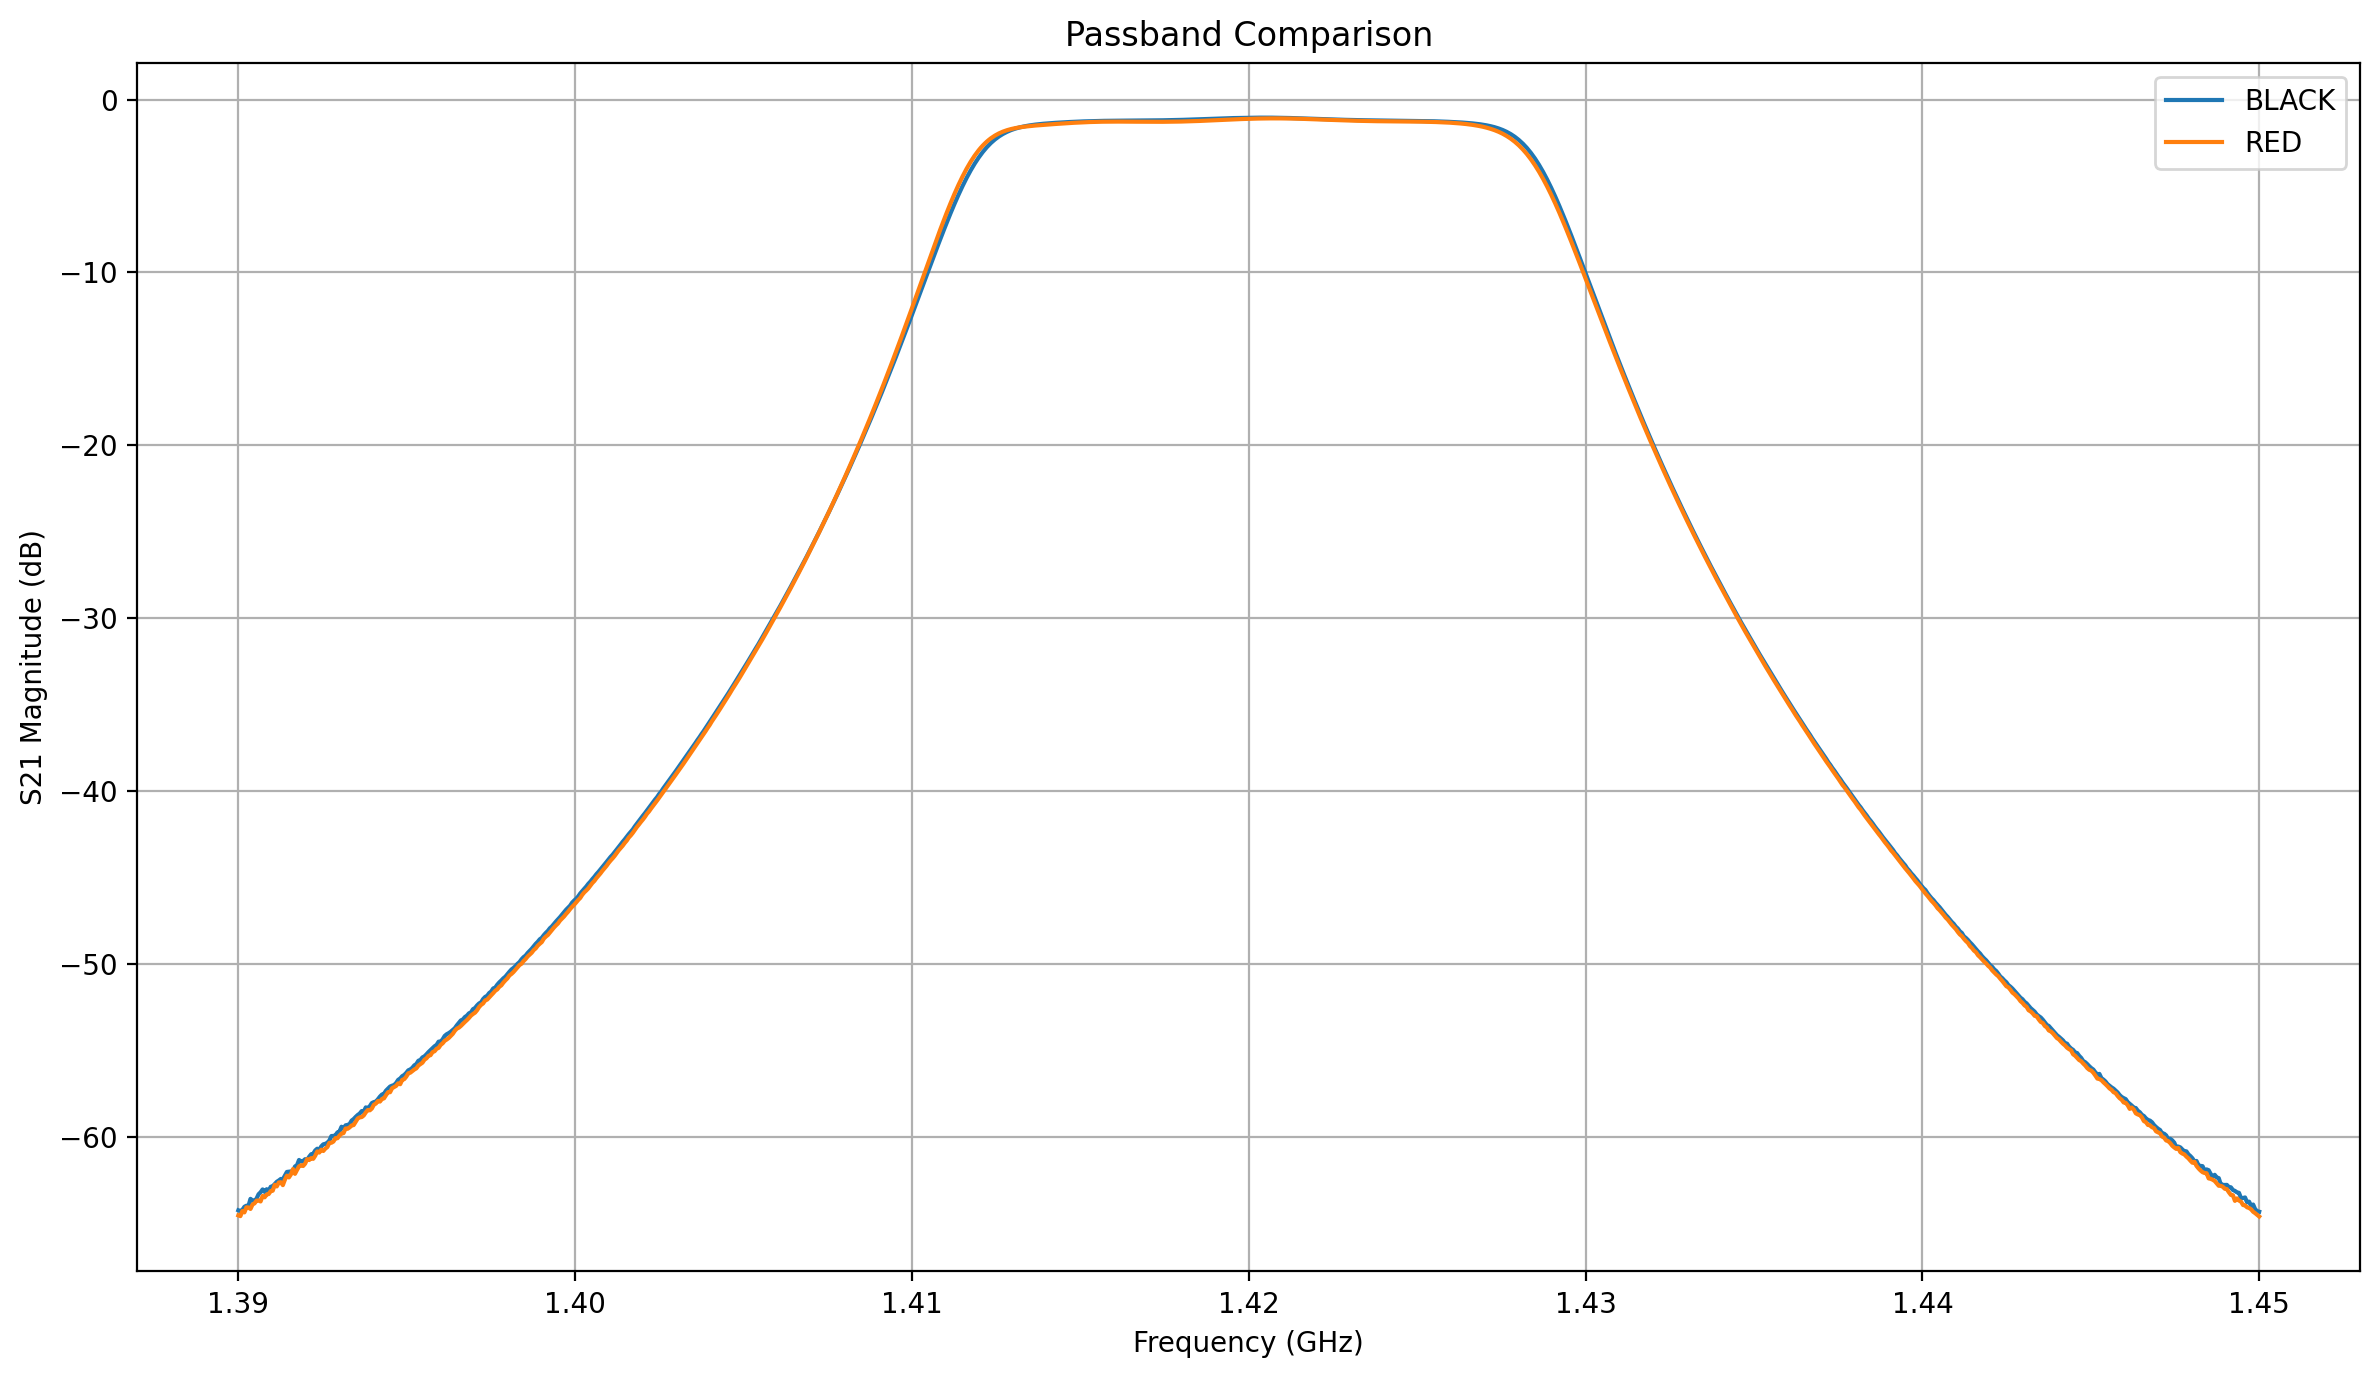

In [5]:
plt.plot(amp2["freq_GHz"], amp2["mag_dB"], label="BLACK")
plt.plot(amp1["freq_GHz"], amp1["mag_dB"], label="RED")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Magnitude (dB)")
plt.title("Passband Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
#-3dB

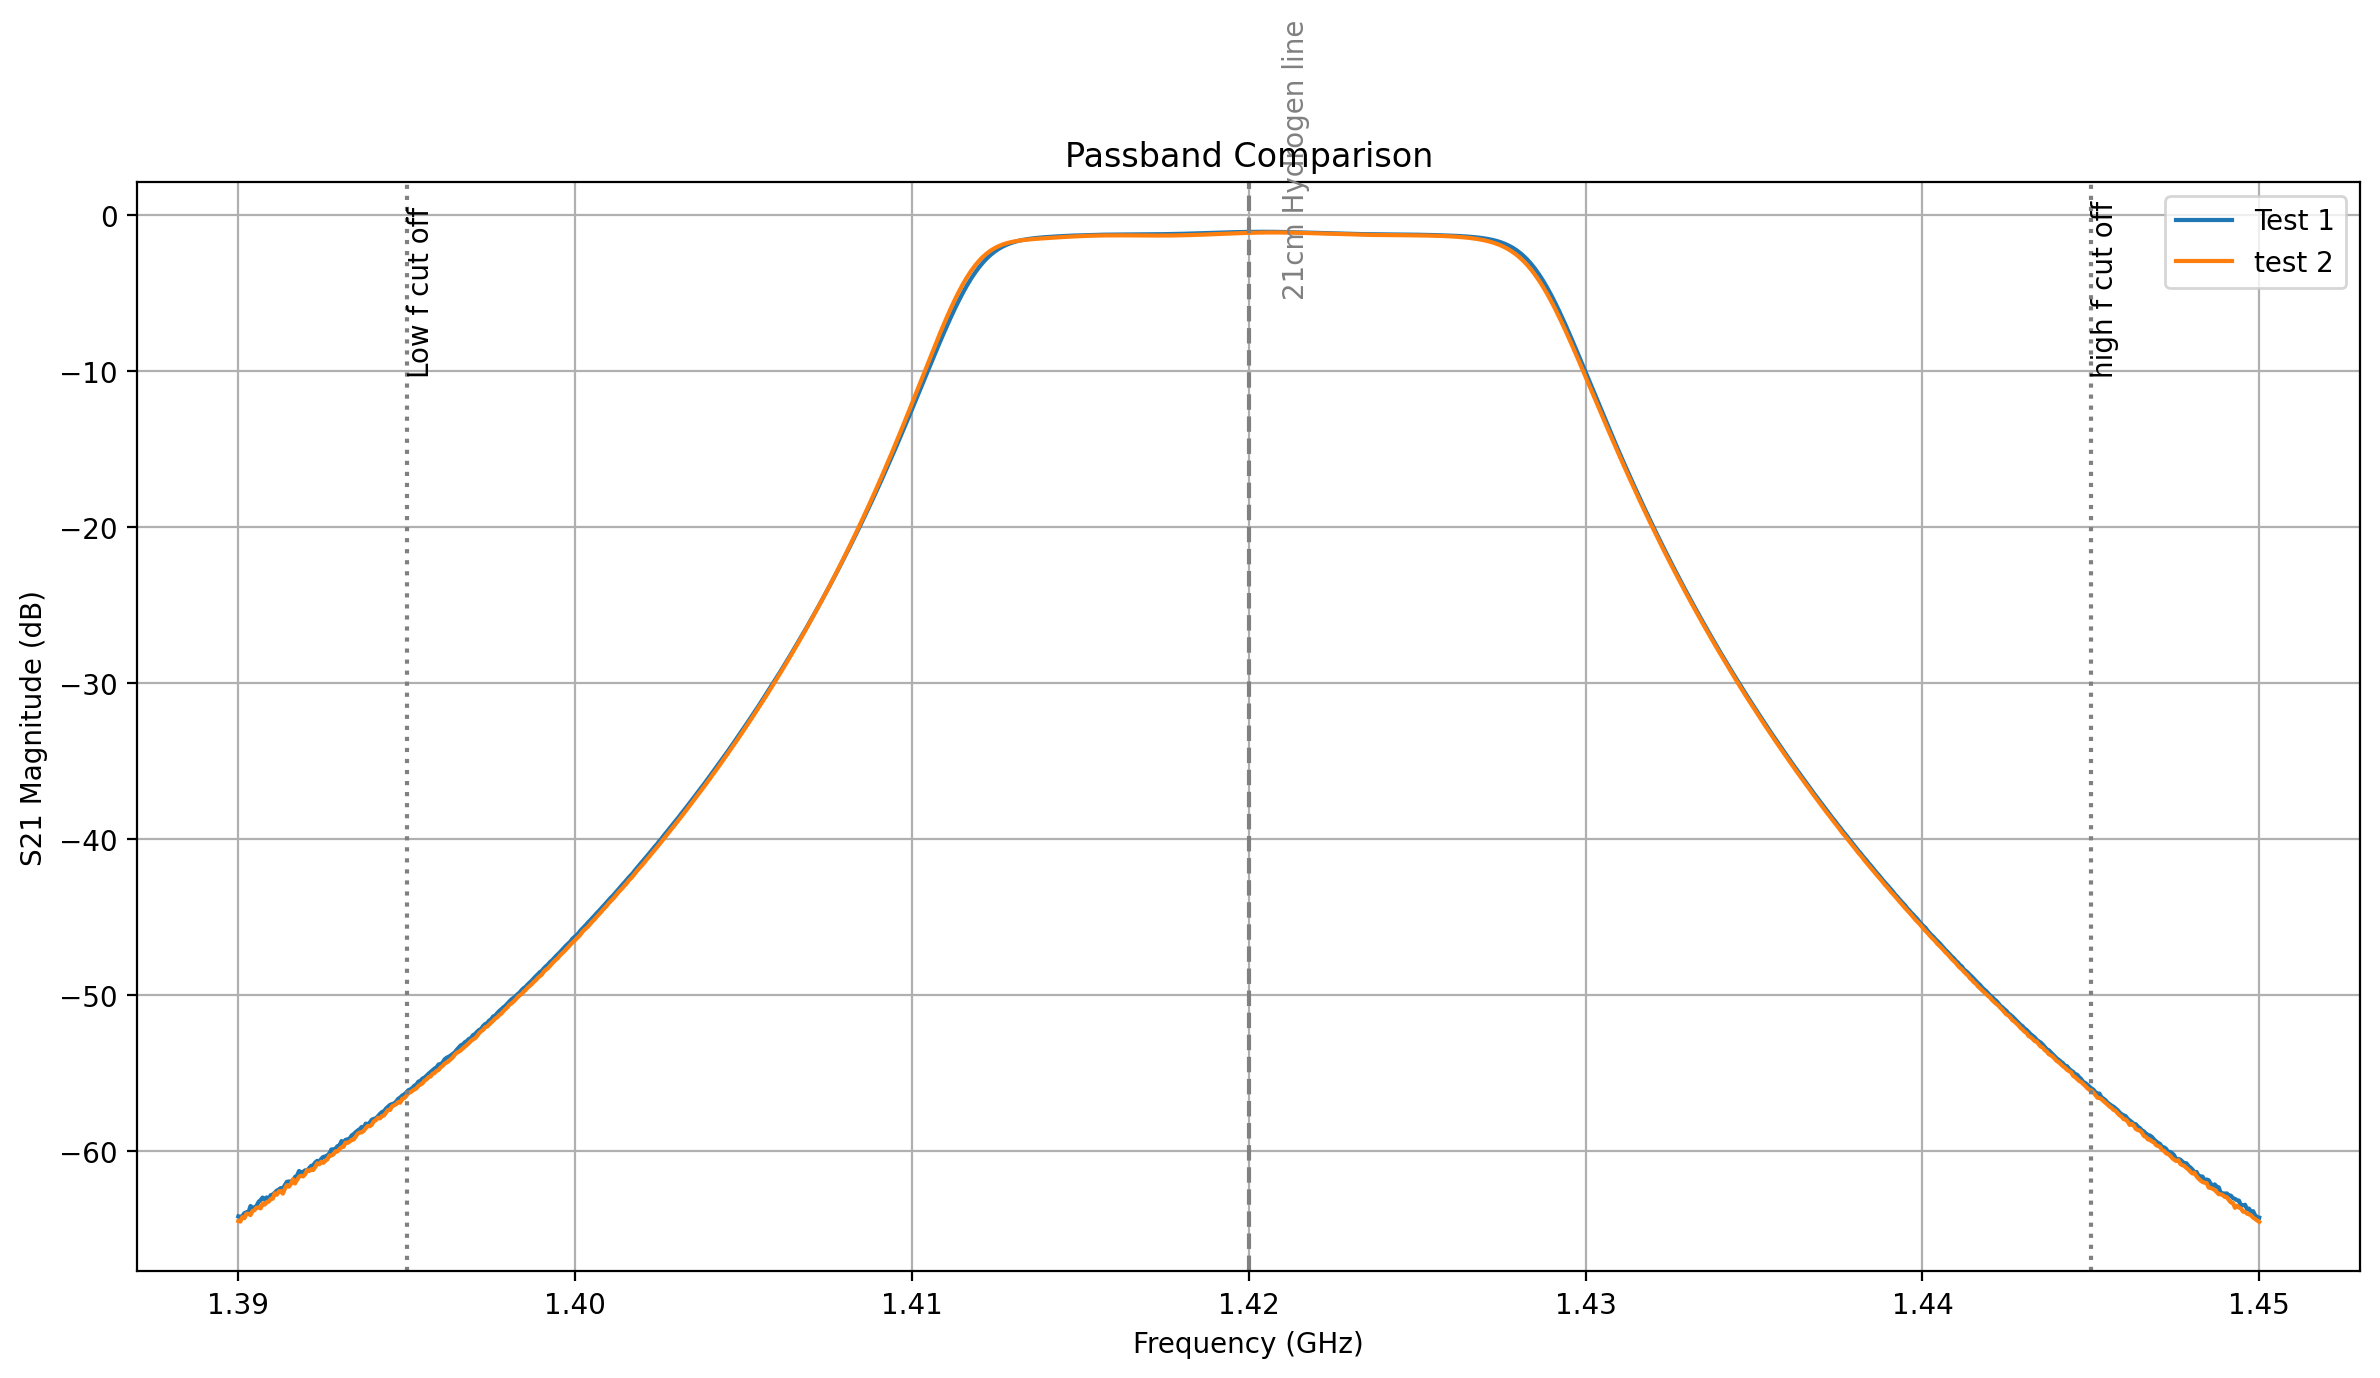

In [6]:
plt.plot(amp2["freq_GHz"], amp2["mag_dB"], label="Test 1")
plt.plot(amp1["freq_GHz"], amp1["mag_dB"], label="test 2") #opposite!!




plt.axvline(1.420, linestyle="--", color="gray")
plt.text(1.421, -5, "21cm Hydrogen line", rotation=90, color="gray")


plt.axvline(1.395, linestyle=":", color="gray")
plt.axvline(1.445, linestyle=":", color="gray")
plt.text(1.395, -10, "Low f cut off", rotation=90)
plt.text(1.445, -10, "high f cut off", rotation=90)

plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Magnitude (dB)")
plt.title("Passband Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
def plot_passband(df,title):
    df=df.copy()

    peak=df["mag_dB"].max()
    df["mag_norm_dB"]=df["mag_dB"]-peak

    passband=df[df["mag_norm_dB"]>=-3]
    passband1=df[df["mag_norm_dB"]>=-2.5]

    f_l=passband["freq_GHz"].min()
    f_h=passband["freq_GHz"].max()
    BW=f_h-f_l

    f_l1=passband1["freq_GHz"].min()
    f_h1=passband1["freq_GHz"].max()
    BW1=f_h1-f_l1
    
    mag_err=0.01
    ppm=1e-6
    freq_err=ppm*df["freq_GHz"]

    df_step=df["freq_GHz"].diff().dropna()
    del_f=df_step.median()
    err=del_f/2

    err_l=np.sqrt(err**2+(ppm*f_l)**2)
    err_h=np.sqrt(err**2+(ppm*f_h)**2)
    BW_err=np.sqrt(err_l**2+err_h**2)

    err_l1=np.sqrt(err**2+(ppm*f_l1)**2)
    err_h1=np.sqrt(err**2+(ppm*f_h1)**2)
    BW1_err=np.sqrt(err_l1**2+err_h1**2)

    f_l_M= f_l*1e3
    f_h_M= f_h*1e3
    f_l1_M= f_l1*1e3
    f_h1_M= f_h1*1e3
    BW_M=BW*1e3
    BW1_M=BW1*1e3
    BW_err_M=BW_err*1e3
    BW1_err_M=BW1_err*1e3

    plt.figure(figsize=(10,6))
    plt.errorbar(df["freq_GHz"]*1e3,df["mag_norm_dB"],yerr=mag_err,xerr=freq_err*1e3,linewidth=1.2,elinewidth=0.5,capsize=2,
                 label=r"$Normalised\ S|21|=\pm0.01$ dB, $frequency=\pm1$ ppm")

    plt.axhline(-3,linestyle='--',c='r',label='-3 dB')
    plt.axhline(-2.5,linestyle='--',c='b',label='-2.5 dB')

    plt.axvspan(f_l_M,f_h_M,color='pink',alpha=0.6,label='-3 dB Passband')
    plt.axvspan(f_l1_M,f_h1_M,color='orange',alpha=0.2,label='-2.5 dB Passband')

    plt.axvline(f_l_M,linestyle='--',c='r')
    plt.axvline(f_h_M,linestyle='--',c='r')
    plt.axvline(f_l1_M,linestyle='--',c='b')
    plt.axvline(f_h1_M,linestyle='--',c='b')
    plt.text(f_l_M,-2.9,f"{f_l_M:.0f} MHz",c='r',ha='right')
    plt.text(f_h_M,-2.9,f"{f_h_M:.0f} MHz",c='r',ha='left')
    plt.text(f_l1_M,-2.5,f"{f_l1_M:.0f} MHz",c='b',ha='right')
    plt.text(f_h1_M,-2.5,f"{f_h1_M:.0f} MHz",c='b',ha='left')

    plt.text((f_l_M+f_h_M)/2,-0.5,f"-3 dB BW = {BW_M:.2f}±{BW_err_M:.2f} MHz",ha='center',fontsize=13)
    plt.text((f_l1_M+f_h1_M)/2,-0.7,f"-2.5 dB BW = {BW1_M:.2f}±{BW1_err_M:.2f} MHz",ha='center',fontsize=13)

    plt.xlabel("Frequency (MHz)",fontsize=15)
    plt.ylabel("Normalized |S21| (dB)",fontsize=15)
    plt.xlim(1410,1430)
    plt.ylim(-3.5,0.15)
    plt.title(f"{title}: -3 dB and -2.5 dB Passband Comparison",fontsize=16)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return f_l,f_h,BW_M,BW_err_M,f_l1,f_h1,BW1_M,BW1_err_M

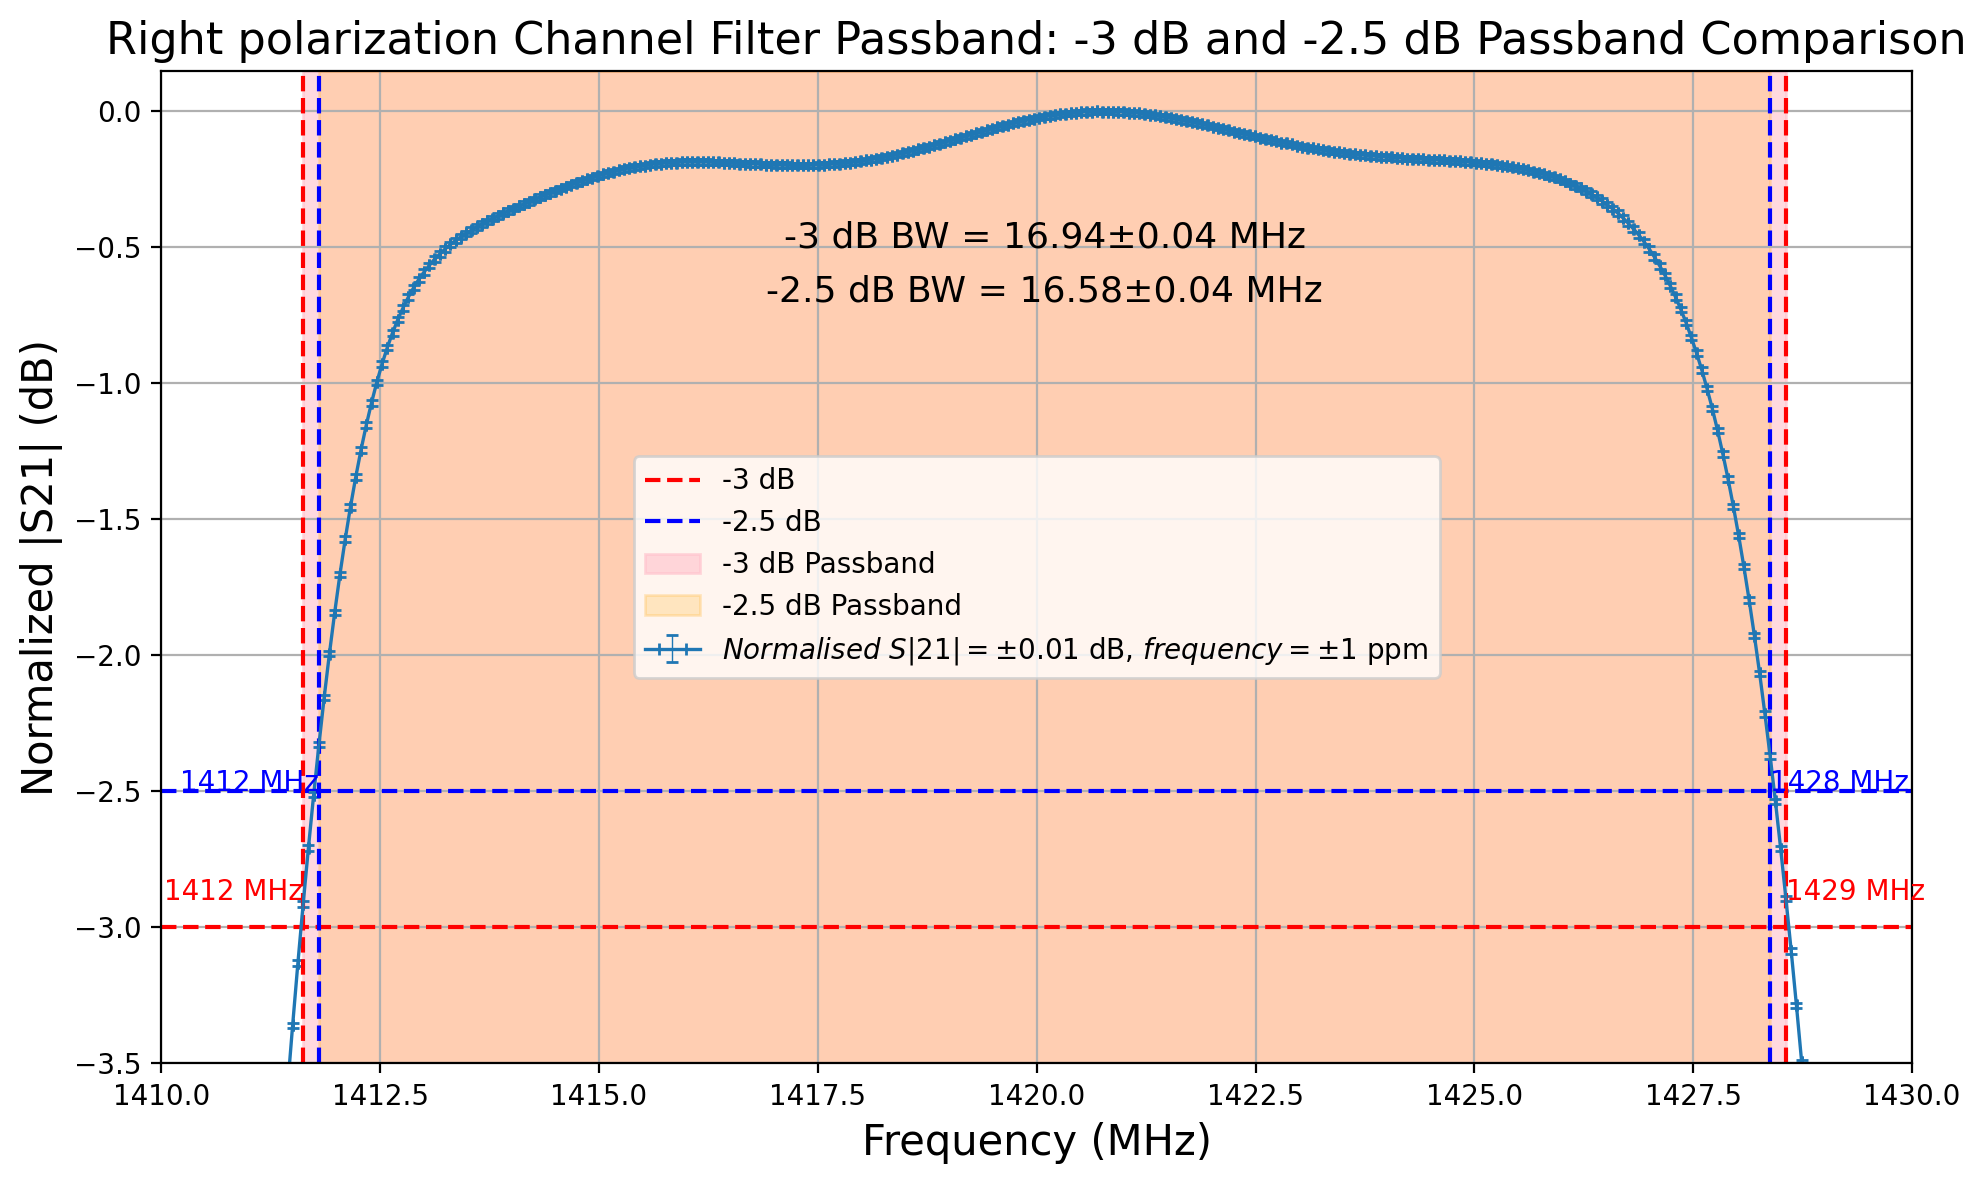

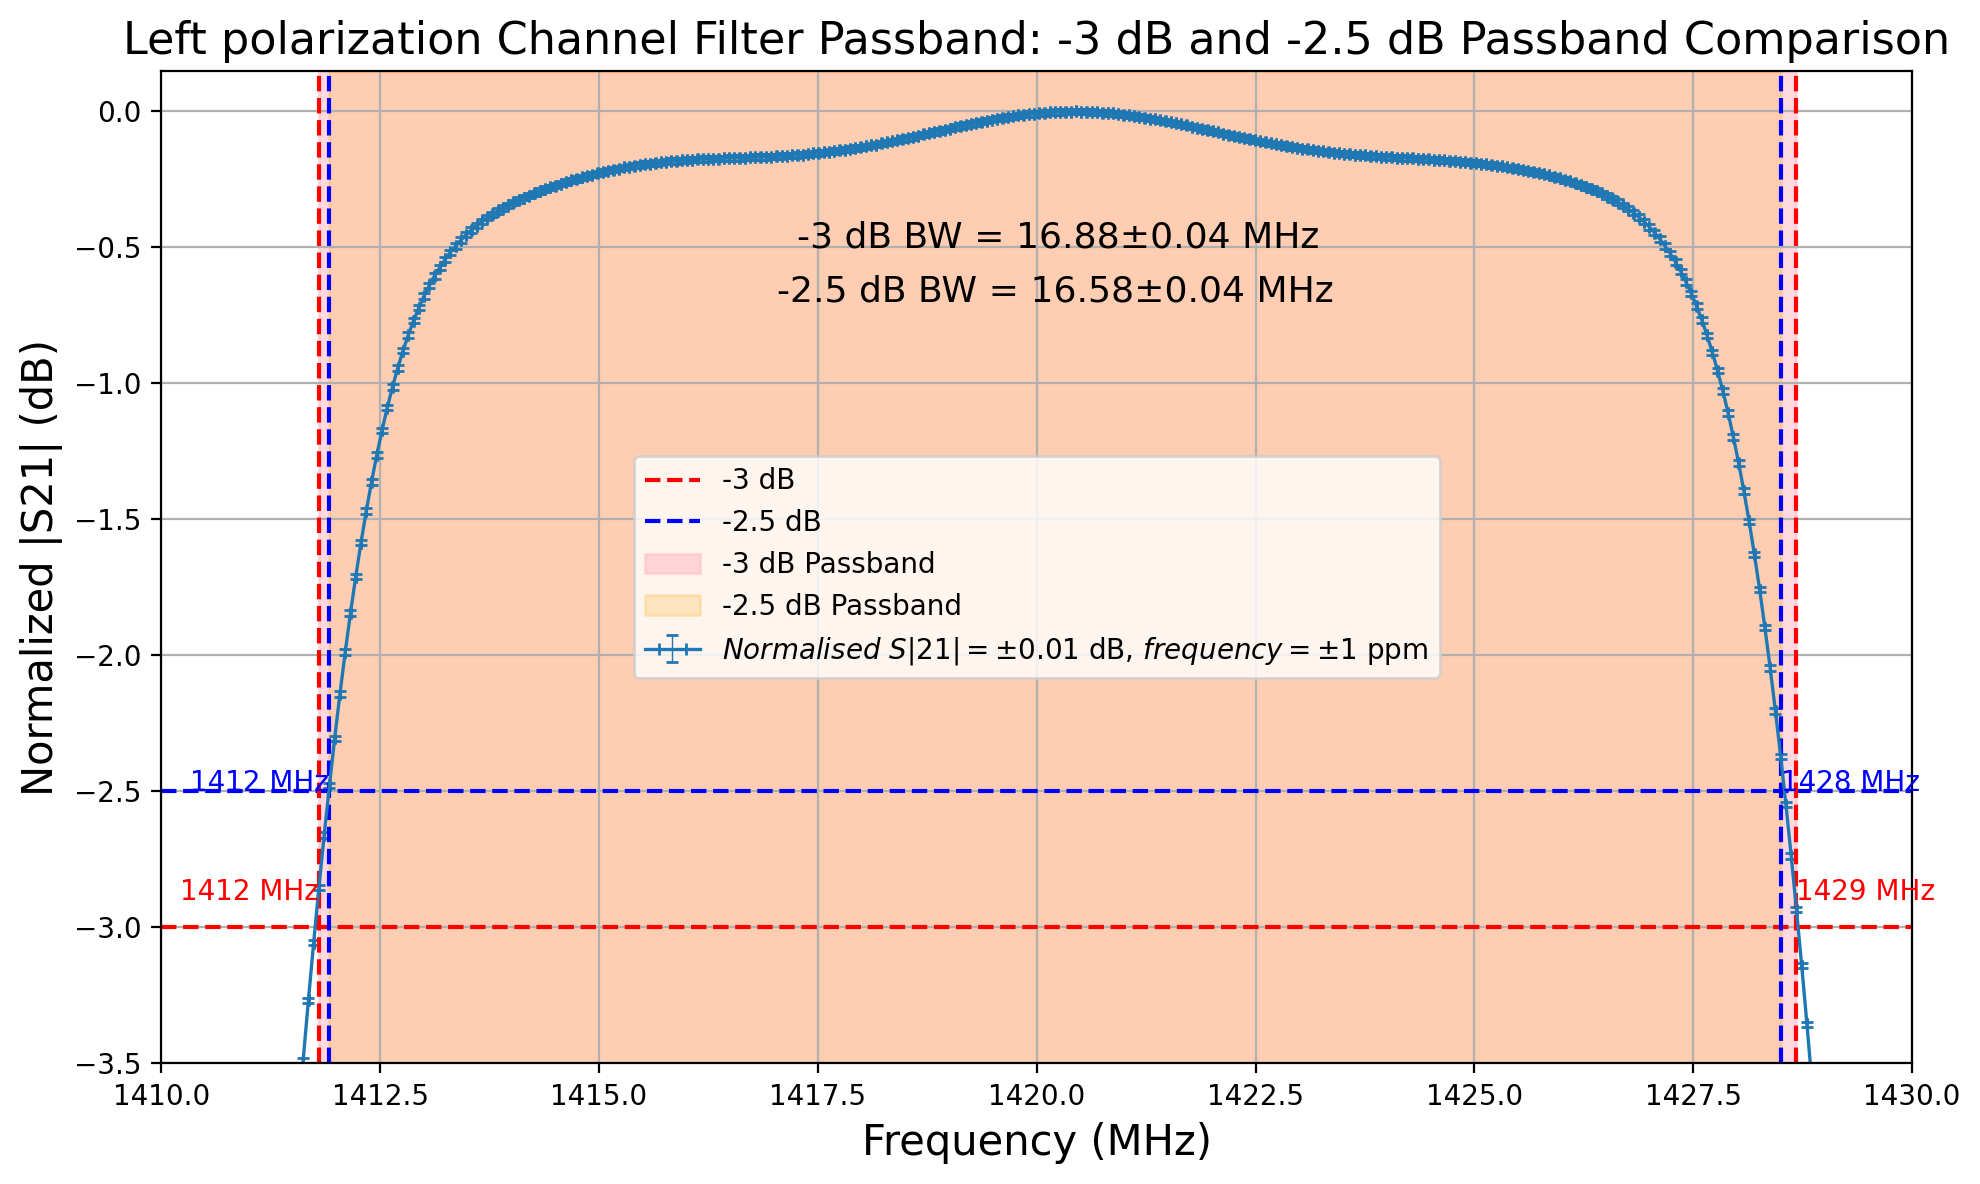

(np.float64(1.411801802801802),
 np.float64(1.428678679678679),
 np.float64(16.876876876877),
 np.float64(0.042516346436455375),
 np.float64(1.411921922921922),
 np.float64(1.428498499498498),
 np.float64(16.576576576575963),
 np.float64(0.04251634437112421))

In [14]:
plot_passband(amp1,"Right polarization Channel Filter Passband")

plot_passband(amp2,"Left polarization Channel Filter Passband")